In [2]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
# df.info()
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(strategy='median')
df["Income"] = imp_mean.fit_transform(df[["Income"]])
df.isnull().sum().sum()

0

# Feature Engineering

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [9]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [37]:
df["Age"] = 2026 - df["Year_Birth"]
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
df["Total_Children"] = df["Teenhome"] + df["Kidhome"]

In [39]:
df["Education"].value_counts()
df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate", "2n Cycle":"Undergraduate","Graduation":"Graduate","Master":"Postgraduate","PhD":"Postgraduate"
})

In [41]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [43]:
df["Marital_Status"].value_counts()
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [45]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

# Drop columns

In [48]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
drop_cols = cols+spending_cols
df_cleaned = df.drop(columns=drop_cols)
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_child,Living_With,Total_Children
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,0
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,0
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,1
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,1


# Outlier removal

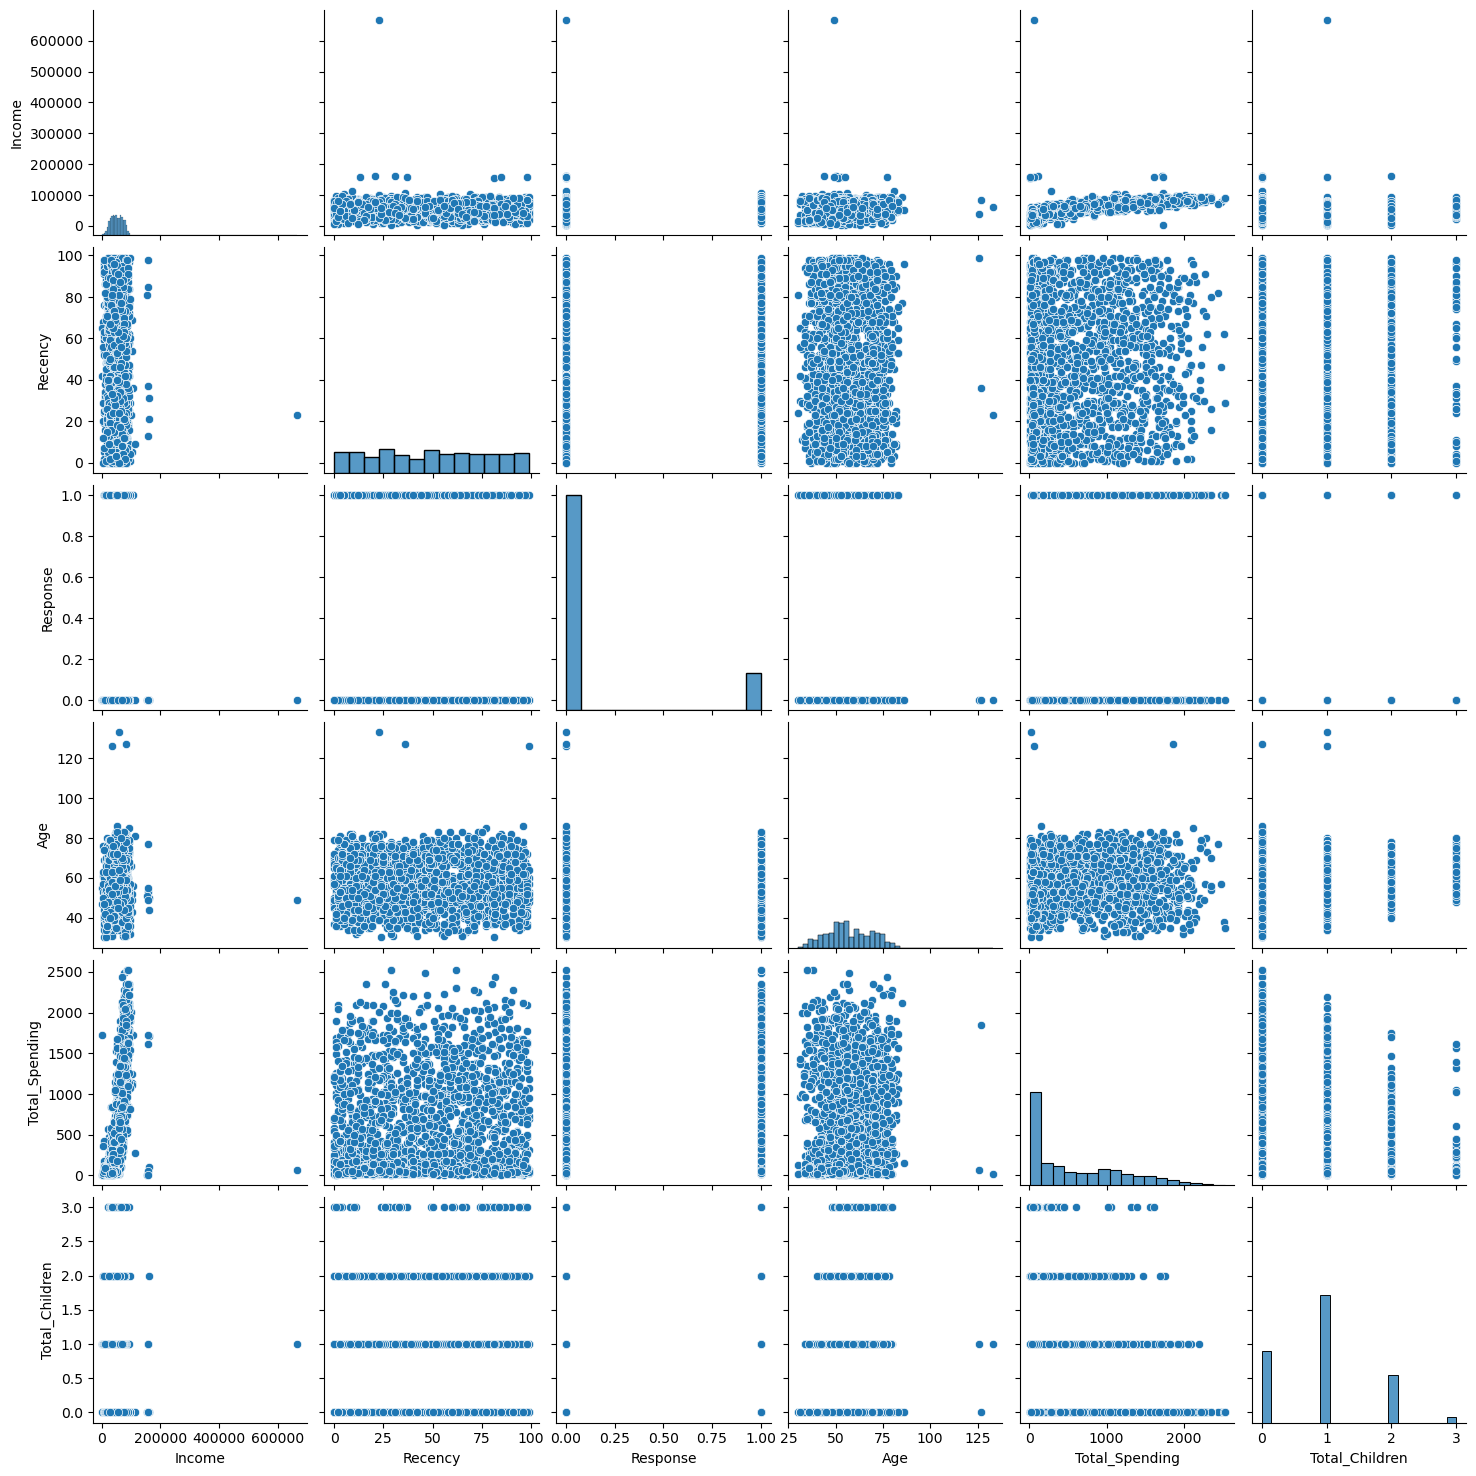

In [50]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]
sns.pairplot(df_cleaned[cols])

In [55]:
df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

<Axes: >

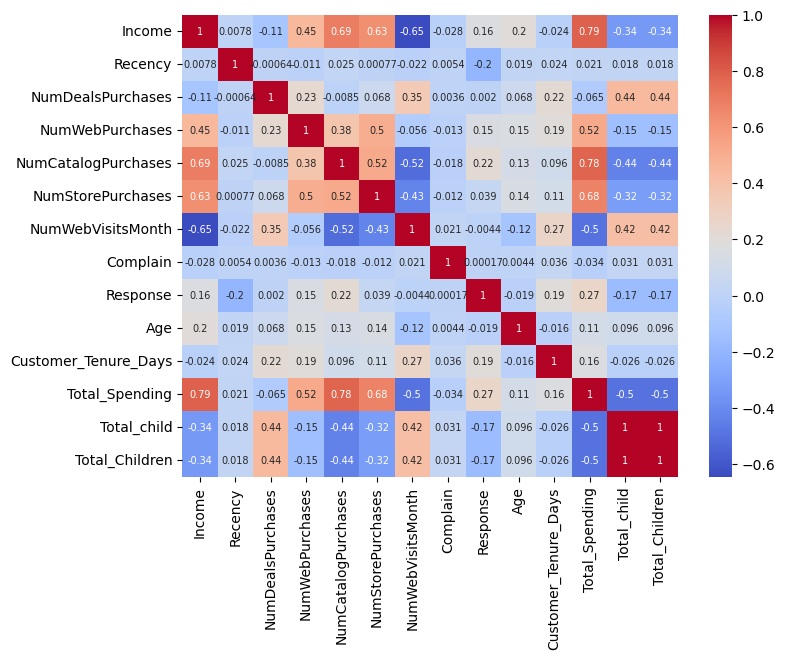

In [65]:
import matplotlib.pyplot as plt
corr = df_cleaned.corr(numeric_only = True)
plt.figure(figsize = (8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size":7},
    cmap = "coolwarm"
)

In [75]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cat_cols = ["Education", "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])
enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_child,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,1,0.0,1.0,0.0,0.0,1.0


In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df_encoded
X_scaled = scaler.fit_transform(X)

Text(0.5, 0.92, '3d projection')

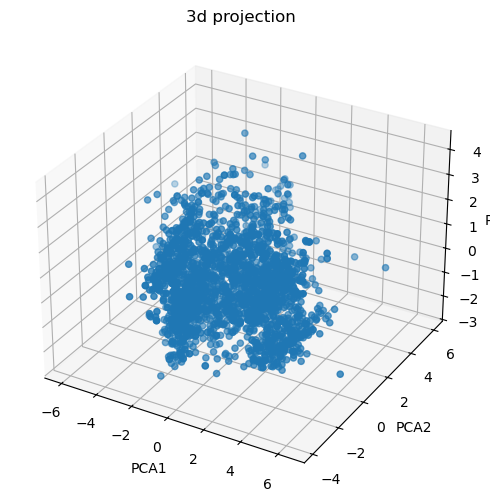

In [129]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
# plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

<Axes: >

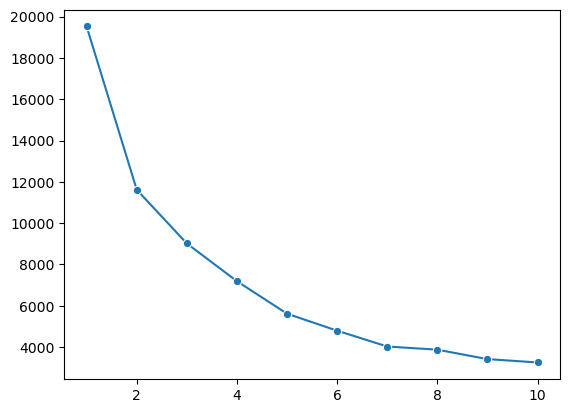

In [131]:
# Elbow method
from sklearn.cluster import KMeans
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state = 42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
sns.lineplot(x = range(1,11), y = wcss, marker = "o")

In [133]:
from kneed import KneeLocator
knee = KneeLocator(range(1,11), wcss, curve = "convex", direction = "decreasing")
print("Optimized K =", knee.elbow)

Optimized K = 4


<Axes: >

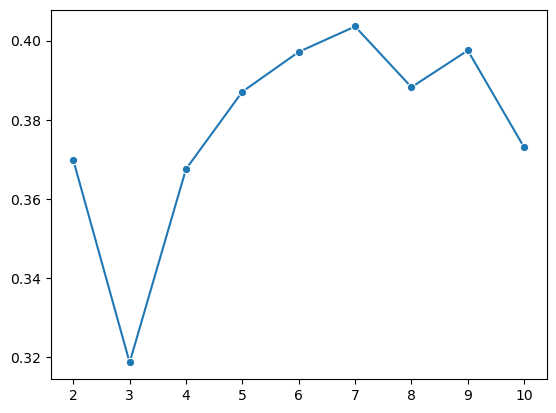

In [135]:
# Silhouette score
from sklearn.metrics import silhouette_score
ss = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k)
    labels = kmeans.fit_predict(X_pca)
    scores = silhouette_score(X_pca, labels)
    ss.append(scores)
sns.lineplot(x = range(2,11), y = ss, marker= "o")

Text(0, 0.5, 'SS')

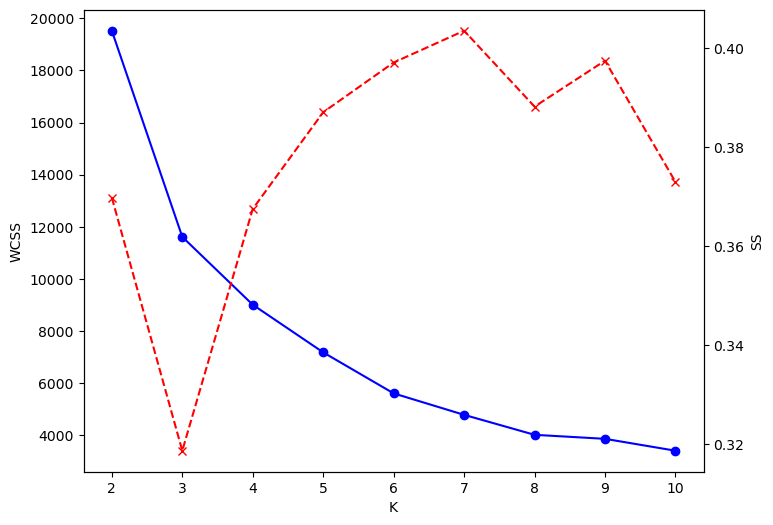

In [136]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range , wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, ss[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

Text(0.5, 0.92, '3d projection')

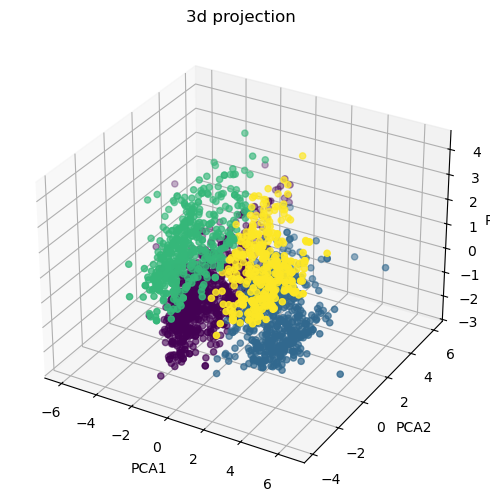

In [139]:
kmeans = KMeans(n_clusters=4, random_state = 42)
labels = kmeans.fit_predict(X_pca)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c = labels)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

Text(0.5, 0.92, '3d projection')

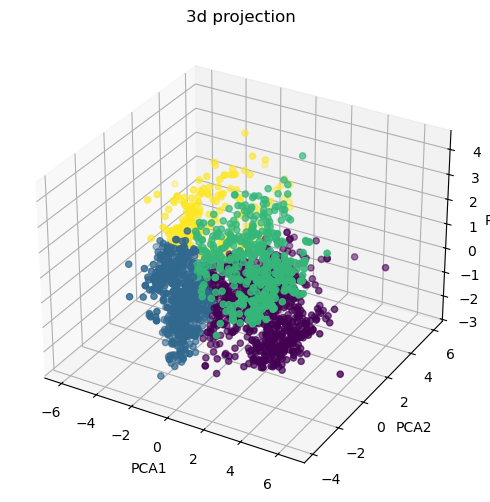

In [143]:
# Aggmerative Clustering
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=4)
labels = agg.fit_predict(X_pca)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c = labels)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Characterization of clusters

In [146]:
X["cluster"] = labels
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_child,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0,1.0,0.0,0.0,1.0,0.0,2
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,2,1.0,0.0,0.0,1.0,0.0,3
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0,1.0,0.0,0.0,0.0,1.0,0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1,1.0,0.0,0.0,0.0,1.0,1
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

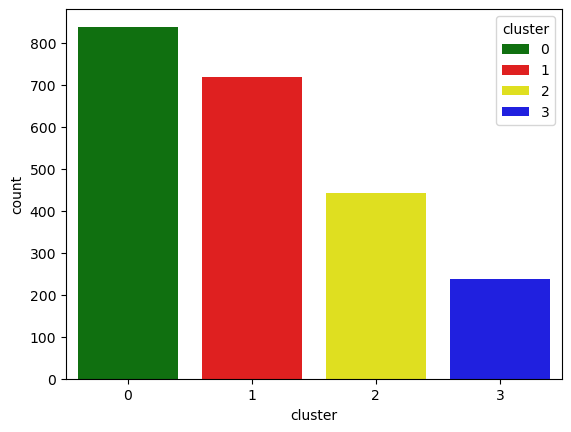

In [160]:
pal = ["green", "red", "yellow", "blue"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

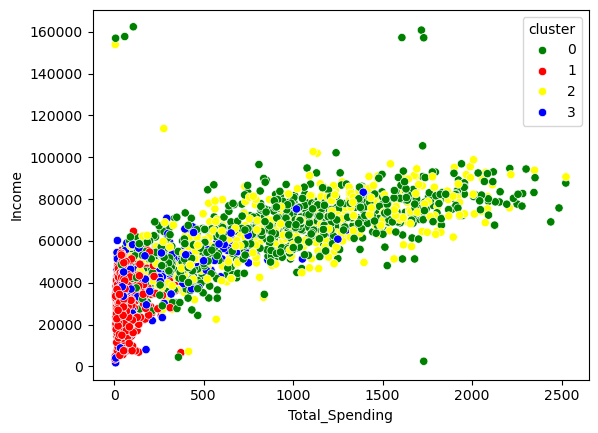

In [162]:
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)


In [170]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        64686.833135  49.355185           2.266985         5.381406   
1        31033.858635  48.988858           1.714485         1.754875   
2        66038.904977  49.855204           2.036199         5.570136   
3        43975.888186  47.278481           4.928270         3.810127   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   4.163290           7.599523           4.270560  0.007151   
1                   0.352368           2.891365           6.635097  0.013928   
2                   4.352941           7.812217           4.242081  0.004525   
3                   1.202532           4.447257           7.050633  0.008439   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         

# Conclusion

Cluster 0 - High-Value Loyal Customers
Income: ~64.7k
Total Spending: ~940
Store Purchases: ~7.6
Catalog Purchases: ~4.2
Response Rate: ~12.6%
Mostly live with a partner.
Few children.

Profile: These are affluent, regular shoppers who spend a lot across multiple channels. They are valuable customers but not the most responsive to campaigns.

Strategy:

Loyalty programs
Premium product recommendations
Personalized offers
Cluster 1 — Low-Income, Low-Spending Customers
Income: ~31k (lowest)
Total Spending: ~66 (very low)
Catalog Purchases: ~0.35
Store Purchases: ~2.9
Web Visits: ~6.6 (high)
Response Rate: ~7.2% (lowest)

Profile: These customers browse frequently but rarely buy. They have lower purchasing power and low engagement with marketing campaigns.

Strategy:

Discount campaigns
Budget-friendly products
Cart abandonment offers
Conversion-focused marketing
Cluster 2 — Premium High-Spending Singles (Best Customers)
Income: ~66k (highest)
Total Spending: ~1025 (highest)
Response Rate: ~29.4% (highest)
Store Purchases: ~7.8
Catalog Purchases: ~4.35
Living Alone: 100%

Profile: These are your most profitable customers. They spend the most and respond strongly to campaigns.

Strategy:

VIP membership
Exclusive promotions
Early access to products
Retention campaigns

Most valuable segment

Cluster 3 — Family-Oriented Moderate Spenders
Income: ~44k
Total Spending: ~281
Children: ~2.1 (highest)
Response Rate: ~19.4%
Web Visits: ~7.0 (highest)

Profile: Families with multiple children. Moderate income and spending but relatively responsive to marketing.

Strategy:

Family bundles
Seasonal promotions
Child-related products
Value packs